# **Búsqueda de Arquitectura Neural (NAS) Basada en Bloques**

**Objetivo:** Evolucionar una Red Neuronal Convolucional (CNN) para el dataset **MNIST** utilizando un enfoque de **búsqueda por bloques**. En lugar de que cada gen represente una capa individual, el algoritmo genético definirá los parámetros de **bloques de construcción predefinidos**.

El genoma de cada individuo definirá la configuración de una secuencia de bloques:
1.  **Bloque Convolucional 1:** Nº de filtros, tamaño de kernel, y si se usa Max Pooling.
2.  **Bloque Convolucional 2:** Nº de filtros, tamaño de kernel, y si se usa Max Pooling.
3.  **Bloque Denso 1:** Nº de neuronas y tasa de dropout.
4.  **Hiperparámetros Globales:** Tasa de aprendizaje y tamaño del lote.

Este método modular permite al algoritmo buscar arquitecturas de una manera más estructurada y jerárquica.

## **1. Configuración Inicial e Instalación de Librerías**

Cargamos las librerías necesarias.

In [1]:
!pip install deap torch torchvision pandas numpy matplotlib seaborn

In [2]:
# Importar librerías
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

from deap import base, creator, tools, algorithms

import matplotlib.pyplot as plt
import seaborn as sns

## **2. Carga del Dataset MNIST**

Cargamos y preparamos el dataset MNIST. De nuevo, usaremos un subconjunto para agilizar el proceso de demostración.

In [3]:
# Transformaciones para el dataset MNIST
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

# Cargar los datasets de entrenamiento y prueba
trainset_full = torchvision.datasets.MNIST(root='./data', train=True,
                                            download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                        download=True, transform=transform)

# Usaremos un subconjunto más pequeño para acelerar la búsqueda
subset_indices = list(range(2000))
trainset = torch.utils.data.Subset(trainset_full, subset_indices)

print(f"Tamaño del subset de entrenamiento: {len(trainset)}")
print(f"Tamaño del set de prueba: {len(testset)}")

100%|██████████| 9.91M/9.91M [00:06<00:00, 1.46MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 226kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.76MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.16MB/s]

Tamaño del subset de entrenamiento: 2000
Tamaño del set de prueba: 10000


## **3. Definición de los Bloques de Construcción**

Creamos clases modulares para nuestros bloques. Esto hace que el constructor de la red principal sea mucho más limpio y fácil de entender.

In [4]:
class ConvBlock(nn.Module):
    """Un bloque convolucional con una capa Conv2d, ReLU y opcionalmente MaxPool2d."""
    def __init__(self, in_channels, out_channels, kernel_size, use_pooling):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size, padding='same'),
            nn.ReLU()
        ]
        if use_pooling:
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class DenseBlock(nn.Module):
    """Un bloque denso con una capa Linear, ReLU y Dropout."""
    def __init__(self, in_features, out_features, dropout_rate):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
    def forward(self, x):
        return self.block(x)

## **4. Modelo de CNN Dinámica Basado en Bloques**

Esta nueva CNN se construye apilando los bloques que definimos anteriormente. El genoma que recibe le indica cómo configurar cada uno de estos bloques.

In [5]:
class DynamicBlockCNN(nn.Module):
    def __init__(self, genome):
        super().__init__()
        
        # El genoma define la configuración de cada bloque y los hiperparámetros
        # [c1_f, c1_k, c1_p, c2_f, c2_k, c2_p, d1_n, d1_d, lr, batch_size]
        (conv1_filters, conv1_kernel, conv1_pool,
        conv2_filters, conv2_kernel, conv2_pool,
        dense1_neurons, dense1_dropout,
        _, _) = map(float, genome) # Mapeamos todo a float para facilidad, luego convertimos a int

        conv1_filters, conv1_kernel, conv1_pool = int(conv1_filters), int(conv1_kernel), bool(conv1_pool)
        conv2_filters, conv2_kernel, conv2_pool = int(conv2_filters), int(conv2_kernel), bool(conv2_pool)
        dense1_neurons = int(dense1_neurons)

        # Construcción de la parte convolucional
        self.conv_part = nn.Sequential(
            ConvBlock(1, conv1_filters, conv1_kernel, conv1_pool),
            ConvBlock(conv1_filters, conv2_filters, conv2_kernel, conv2_pool)
        )
        
        # Calcular dinámicamente el tamaño de entrada para la parte densa
        feature_size = self._get_feature_size()
        
        # Construcción de la parte densa
        self.dense_part = nn.Sequential(
            nn.Flatten(),
            DenseBlock(feature_size, dense1_neurons, dense1_dropout),
            nn.Linear(dense1_neurons, 10) # 10 clases de salida para MNIST
        )

    def _get_feature_size(self):
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 28, 28)
            output_size = self.conv_part(dummy_input).view(1, -1).size(1)
        return output_size

    def forward(self, x):
        x = self.conv_part(x)
        x = self.dense_part(x)
        return x

## **5. Función de Evaluación de Fitness (Actualizada)**

La lógica de esta función es la misma, pero ahora crea una instancia de `DynamicBlockCNN` y desempaqueta el nuevo genoma de 10 elementos.

In [6]:
def evaluate_fitness(individual):
    """
    Evalúa el fitness de un individuo (arquitectura de bloques + hiperparámetros).
    """
    try:
        # El genoma completo: 10 genes
        lr, batch_size = individual[8], int(individual[9])
        
        model = DynamicBlockCNN(individual)
        
        train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        num_epochs = 2
        
        model.train()
        for epoch in range(num_epochs):
            for images, labels in train_loader:
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
        
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = correct / total
        return (accuracy,)

    except Exception as e:
        # Asignar fitness 0 a arquitecturas inválidas
        return (0.0,)

## **6. Configuración de DEAP para NAS Basado en Bloques**

### **6.1. Definición del Genoma por Bloques**

El genoma ahora tiene 10 elementos que configuran nuestros bloques.

In [7]:
# [c1_f, c1_k, c1_p, c2_f, c2_k, c2_p, d1_n, d1_d, lr, bs]
BOUNDS_LOW =  [8,  3, 0, 16, 3, 0, 32,  0.1,  0.0001, 16]
BOUNDS_HIGH = [32, 5, 1, 64, 5, 1, 128, 0.5,  0.01,   128]
NUM_PARAMS = 10

### **6.2. Creación del Toolbox de DEAP**

Actualizamos el toolbox para generar nuestro nuevo genoma de 10 elementos.

In [8]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# --- Genes para Bloque Conv 1 ---
toolbox.register("attr_c1_f", random.randint, BOUNDS_LOW[0], BOUNDS_HIGH[0])
toolbox.register("attr_c1_k", random.choice, [3, 5])
toolbox.register("attr_c1_p", random.randint, BOUNDS_LOW[2], BOUNDS_HIGH[2])
# --- Genes para Bloque Conv 2 ---
toolbox.register("attr_c2_f", random.randint, BOUNDS_LOW[3], BOUNDS_HIGH[3])
toolbox.register("attr_c2_k", random.choice, [3, 5])
toolbox.register("attr_c2_p", random.randint, BOUNDS_LOW[5], BOUNDS_HIGH[5])
# --- Genes para Bloque Denso 1 ---
toolbox.register("attr_d1_n", random.randint, BOUNDS_LOW[6], BOUNDS_HIGH[6])
toolbox.register("attr_d1_d", random.uniform, BOUNDS_LOW[7], BOUNDS_HIGH[7])
# --- Genes de Hiperparámetros ---
toolbox.register("attr_lr", random.uniform, BOUNDS_LOW[8], BOUNDS_HIGH[8])
toolbox.register("attr_bs", random.randint, BOUNDS_LOW[9], BOUNDS_HIGH[9])

# Crear un individuo (genoma completo)
toolbox.register("individual", tools.initCycle, creator.Individual,
                (toolbox.attr_c1_f, toolbox.attr_c1_k, toolbox.attr_c1_p,
                toolbox.attr_c2_f, toolbox.attr_c2_k, toolbox.attr_c2_p,
                toolbox.attr_d1_n, toolbox.attr_d1_d,
                toolbox.attr_lr, toolbox.attr_bs), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate_fitness)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.1) # mutFlipBit es bueno para genes binarios/enteros
toolbox.register("select", tools.selTournament, tournsize=3)

## **7. Ejecución del Algoritmo Evolutivo**

Lanzamos la búsqueda. El proceso es el mismo, pero ahora cada individuo es una receta completa para construir una CNN a partir de bloques.

In [9]:
print("--- Iniciando Búsqueda de Arquitectura Neural (NAS) por Bloques---")
start_time_nas = time.time()

POPULATION_SIZE = 15
N_GENERATIONS = 8
P_CROSSOVER = 0.6
P_MUTATION = 0.3

pop = toolbox.population(n=POPULATION_SIZE)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

pop, log = algorithms.eaSimple(pop, toolbox,
                                cxpb=P_CROSSOVER,
                                mutpb=P_MUTATION,
                                ngen=N_GENERATIONS,
                                stats=stats,
                                halloffame=hof,
                                verbose=True)

end_time_nas = time.time()
nas_time = end_time_nas - start_time_nas

--- Iniciando Búsqueda de Arquitectura Neural (NAS) por Bloques---
gen	nevals	avg     	max   
0  	15    	0.884587	0.9367
1  	8     	0.848713	0.9367


/home/santiago/anaconda3/envs/MADSI/lib/python3.11/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")
/home/santiago/anaconda3/envs/MADSI/lib/python3.11/site-packages/torch/nn/modules/conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv2d(


2  	11    	0.725727	0.9386
3  	12    	0.737287	0.9434
4  	13    	0.744533	0.9412
5  	8     	0.751327	0.9412
6  	12    	0.745567	0.9412
7  	7     	0.79824 	0.9463
8  	7     	0.7556  	0.9463


## **8. Resultados de la Búsqueda por Bloques**

Mostramos la mejor arquitectura encontrada, decodificando el genoma en una descripción legible de los bloques.

In [10]:
best_individual = hof[0]
best_fitness = best_individual.fitness.values[0]

# Decodificar el genoma para mostrarlo
(c1_f, c1_k, c1_p, c2_f, c2_k, c2_p, d1_n, d1_d, lr, bs) = best_individual

print(f"\n--- Búsqueda Finalizada en {nas_time:.2f} segundos ---")
print(f"\nMejor Precisión (Fitness) Encontrada: {best_fitness:.4f}")

print("\n--- Mejor Arquitectura y Hiperparámetros Encontrados ---")
print(f"  - Bloque Conv 1: {int(c1_f)} filtros, kernel {int(c1_k)}x{int(c1_k)}, Usa Pooling: {'Sí' if bool(c1_p) else 'No'}")
print(f"  - Bloque Conv 2: {int(c2_f)} filtros, kernel {int(c2_k)}x{int(c2_k)}, Usa Pooling: {'Sí' if bool(c2_p) else 'No'}")
print(f"  - Bloque Denso 1: {int(d1_n)} neuronas, Dropout: {d1_d:.2f}")
print("  --------------------")
print(f"  - Tasa de Aprendizaje: {lr:.6f}")
print(f"  - Tamaño de Lote (Batch Size): {int(bs)}")


--- Búsqueda Finalizada en 275.87 segundos ---

Mejor Precisión (Fitness) Encontrada: 0.9463

--- Mejor Arquitectura y Hiperparámetros Encontrados ---
  - Bloque Conv 1: 16 filtros, kernel 5x5, Usa Pooling: No
  - Bloque Conv 2: 60 filtros, kernel 5x5, Usa Pooling: Sí
  - Bloque Denso 1: 128 neuronas, Dropout: 0.33
  --------------------
  - Tasa de Aprendizaje: 0.009242
  - Tamaño de Lote (Batch Size): 69


### **Visualización del Progreso Evolutivo**

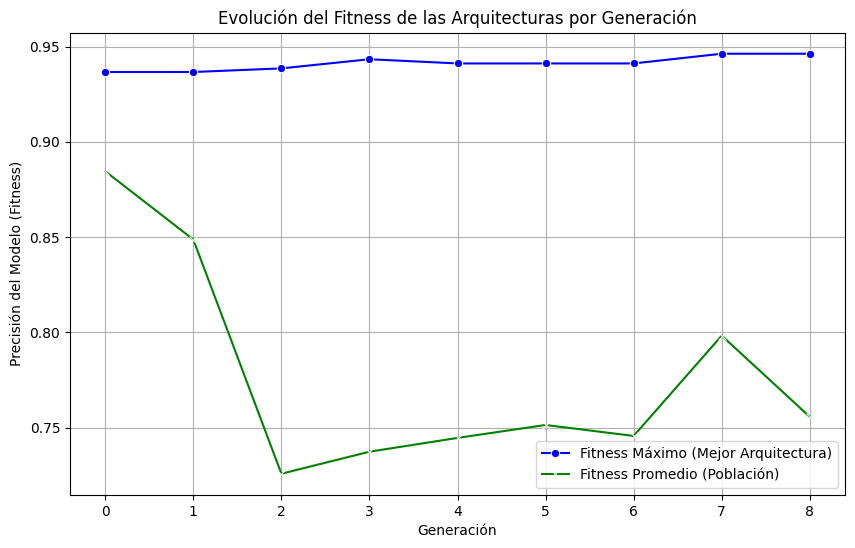

In [11]:
gen = log.select("gen")
max_fitness = log.select("max")
avg_fitness = log.select("avg")

fig, ax1 = plt.subplots(figsize=(10, 6))
sns.lineplot(x=gen, y=max_fitness, ax=ax1, marker='o', color='b', label='Fitness Máximo (Mejor Arquitectura)')
sns.lineplot(x=gen, y=avg_fitness, ax=ax1, marker='x', color='g', label='Fitness Promedio (Población)')

ax1.set_xlabel("Generación")
ax1.set_ylabel("Precisión del Modelo (Fitness)")
ax1.set_title("Evolución del Fitness de las Arquitecturas por Generación")
ax1.legend()
plt.grid(True)
plt.show()